Title - Heart Disease Prediction using Logistic Regression

1. Importing Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


2. Importing Data

In [12]:
heart = pd.read_csv('dataset/heart_disease_data.csv')

print("First 5 rows of the dataset:")
heart.head()

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


3. Data Preprocessing

In [13]:
print(f"Dataset Shape: {heart.shape}")
print(f"→ {heart.shape[0]} rows and {heart.shape[1]} columns\n")

Dataset Shape: (303, 14)
→ 303 rows and 14 columns



In [14]:
print("Dataset Info:")
heart.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [15]:
print("Missing Values per Column:")
print(heart.isnull().sum())
print(f"\nTotal Missing Values: {heart.isnull().sum().sum()}")

Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total Missing Values: 0


In [16]:
print(f"Duplicate Rows: {heart.duplicated().sum()}")

# Drop duplicates if any
heart.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {heart.shape}")

Duplicate Rows: 1
Shape after removing duplicates: (302, 14)


In [17]:
print("Data Types:")
print(heart.dtypes)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [19]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [20]:
print("Target Class Distribution:")
print(heart['target'].value_counts())
print("\n0 = No Heart Disease | 1 = Heart Disease")

Target Class Distribution:
target
1    164
0    138
Name: count, dtype: int64

0 = No Heart Disease | 1 = Heart Disease


4. Exploratory Data Analysis

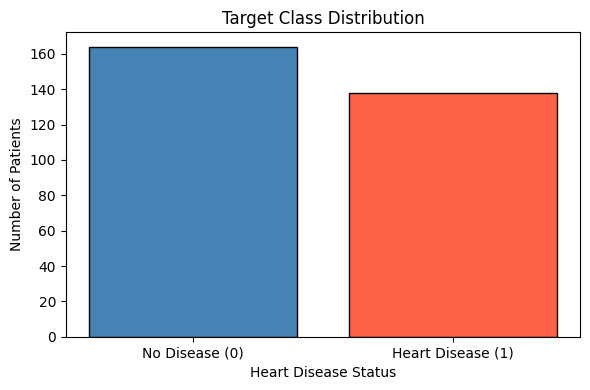

Plot 1 saved as 'output/plot1_target_distribution.png'


In [37]:
counts = heart['target'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('output/plot1_target_distribution.png', dpi=100)
plt.show()
print("Plot 1 saved as 'output/plot1_target_distribution.png'")

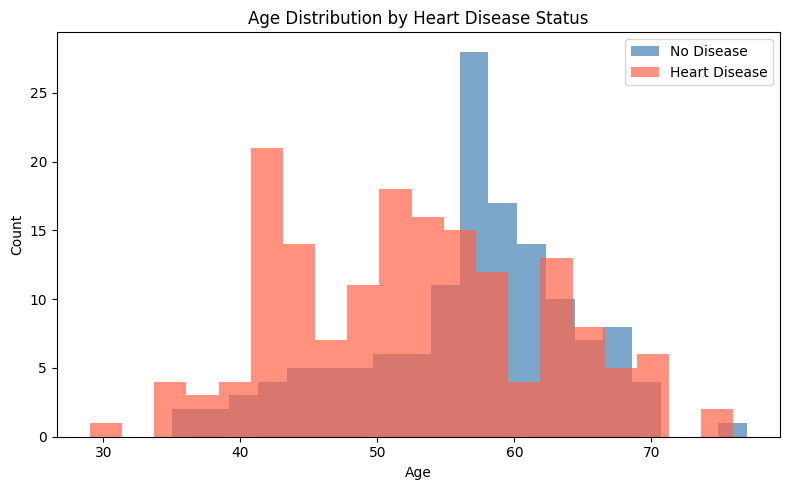

Plot 2 saved as 'output/plot2_age_distribution.png'


In [38]:
plt.figure(figsize=(8, 5))
plt.hist(heart[heart['target'] == 0]['age'], bins=20, color='steelblue', alpha=0.7, label='No Disease')
plt.hist(heart[heart['target'] == 1]['age'], bins=20, color='tomato', alpha=0.7, label='Heart Disease')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('output/plot2_age_distribution.png', dpi=100)
plt.show()
print("Plot 2 saved as 'output/plot2_age_distribution.png'")

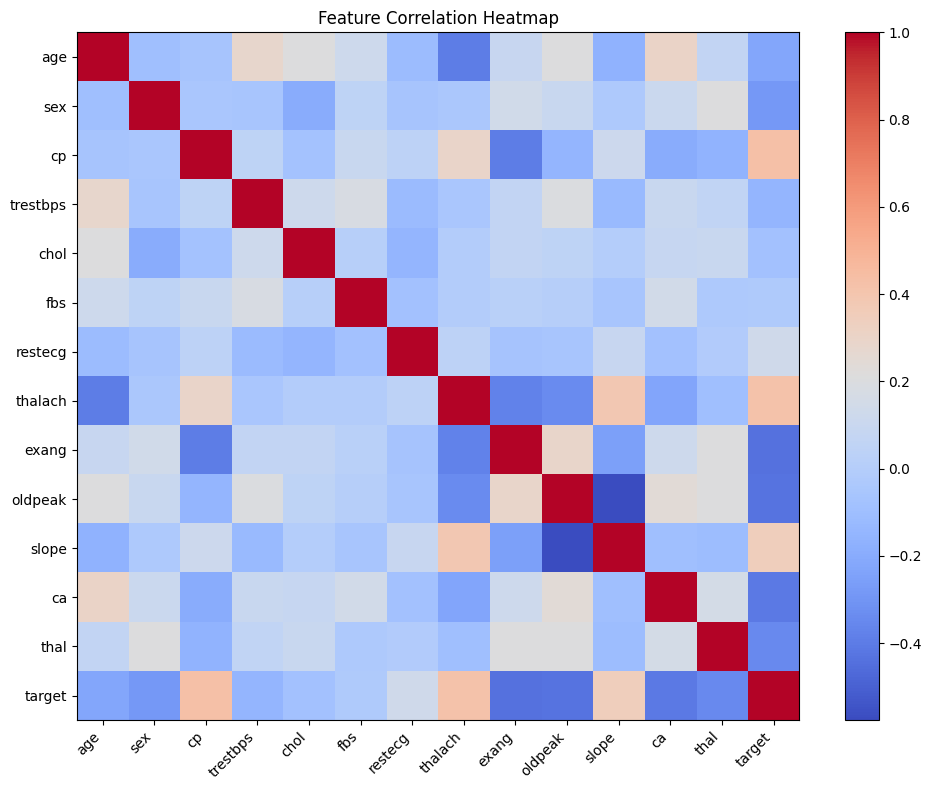

Plot 3 saved as 'output/plot3_correlation_heatmap.png'


In [39]:
corr = heart.corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('output/plot3_correlation_heatmap.png', dpi=100)
plt.show()
print("Plot 3 saved as 'output/plot3_correlation_heatmap.png'")

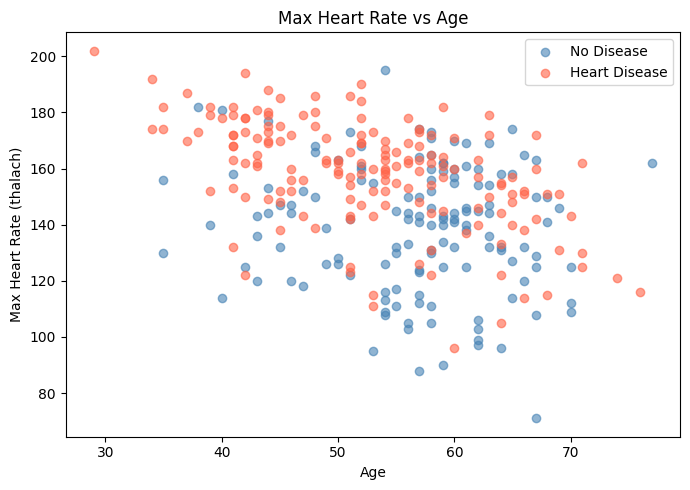

Plot 4 saved as 'output/plot4_heartrate_vs_age.png'


In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(heart[heart['target'] == 0]['age'], heart[heart['target'] == 0]['thalach'],
            color='steelblue', alpha=0.6, label='No Disease')
plt.scatter(heart[heart['target'] == 1]['age'], heart[heart['target'] == 1]['thalach'],
            color='tomato', alpha=0.6, label='Heart Disease')
plt.title('Max Heart Rate vs Age')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalach)')
plt.legend()
plt.tight_layout()
plt.savefig('output/plot4_heartrate_vs_age.png', dpi=100)
plt.show()
print("Plot 4 saved as 'output/plot4_heartrate_vs_age.png'")

5. Train Test Split

In [26]:
X = heart.drop(columns=['target'])

y = heart['target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features (X) shape: (302, 13)
Target (y) shape:   (302,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")

Training set size:  241 samples
Testing set size:   61 samples


6. Feature Scaling

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling applied successfully!")

Feature scaling applied successfully!


7. Model Training

In [30]:
model = LogisticRegression(solver='lbfgs', C=0.1, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


8. Model Evaluation

In [31]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train Accuracy : {train_acc * 100:.2f}%")
print(f"Test  Accuracy : {test_acc  * 100:.2f}%")

Train Accuracy : 84.23%
Test  Accuracy : 77.05%


Confusion Matrix:
[[18 10]
 [ 4 29]]


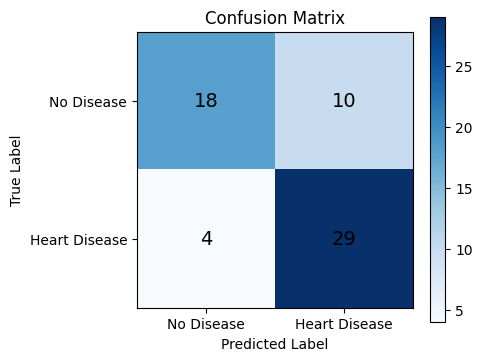

Plot 5 saved as 'output/plot5_confusion_matrix.png'


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.yticks([0, 1], ['No Disease', 'Heart Disease'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, color='black')

plt.tight_layout()
plt.savefig('output/plot5_confusion_matrix.png', dpi=100)
plt.show()
print("Plot 5 saved as 'output/plot5_confusion_matrix.png'")

In [35]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=['No Disease', 'Heart Disease']))

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.82      0.64      0.72        28
Heart Disease       0.74      0.88      0.81        33

     accuracy                           0.77        61
    macro avg       0.78      0.76      0.76        61
 weighted avg       0.78      0.77      0.77        61

